## 1. Read the example seismograms

Read the example synthetic earthquakes from `EXAMPLE_SEISMOGRAMS/synthetic_earthquakes`.

For the initial coherence test, use E1 and E2 as the two events.

In [1]:
from pathlib import Path
from obspy import read

data_dir = Path("EXAMPLE_SEISMOGRAMS/synthetic_earthquakes")
files = sorted(data_dir.glob("*.mseed"))
earthquakes = {path.stem: read(str(path)) for path in files}

st1 = earthquakes["E1_Mw3.5"].copy()
st2 = earthquakes["E5_Mw5.5"].copy()

# Reproduce the 100 s t0 pick used by Section 2.
for stream in (st1, st2):
    for tr in stream:
        tr.stats.t0 = 10.0

# Use the common duration so every station contributes the same sample range.
min_npts = min(tr.stats.npts for tr in st1 + st2)
for stream in (st1, st2):
    for tr in stream:
        tr.trim(endtime=tr.stats.starttime + (min_npts - 1) / tr.stats.sampling_rate)


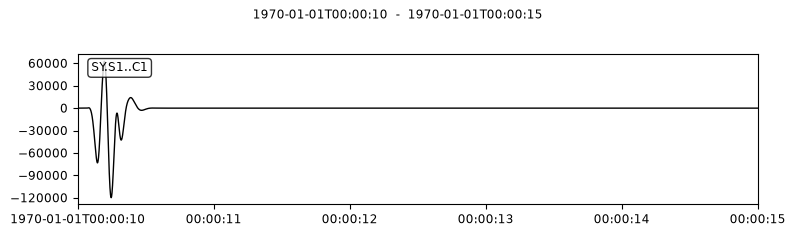

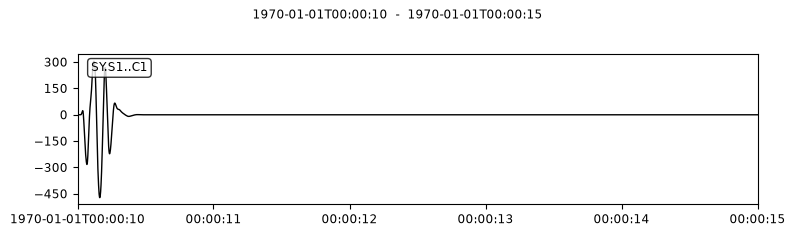

In [2]:
#have a look at some traces
# 
tr1=st2[0]
t1=tr1.stats.starttime+tr1.stats.t0
tr1.plot(starttime=t1,endtime=t1+5);

tr2=st1.select(station=tr1.stats.station)[0]
t2=tr2.stats.starttime+tr2.stats.t0
tr2.plot(starttime=t2,endtime=t2+5);

In [3]:
assert len(st1) > 1 and len(st2) > 1
assert len(files) == 5
assert [tr.stats.station for tr in st1] == [tr.stats.station for tr in st2]
assert all(tr.stats.npts == min_npts for tr in st1 + st2)
assert all(tr.stats.sampling_rate == st1[0].stats.sampling_rate for tr in st1 + st2)
assert all(tr.stats.t0 == 10.0 for tr in st1 + st2)

print(st1)
print(st2)
print(f"Read {len(earthquakes)} earthquake streams.")
print(st1)
print(st2)
print("Example seismogram checks passed.")


10 Trace(s) in Stream:
SY.S1..C1   | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 20591 samples
SY.S2..C2   | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 20591 samples
SY.S3..C3   | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 20591 samples
SY.S4..C4   | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 20591 samples
SY.S5..C5   | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 20591 samples
SY.S6..C6   | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 20591 samples
SY.S7..C7   | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 20591 samples
SY.S8..C8   | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 20591 samples
SY.S9..C9   | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 20591 samples
SY.S10..C10 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:20.590000Z | 1000.0 Hz, 2

## 2. Phase coherence

Calculate the interstation phase coherence for the synthetic waveforms.

This is just to check that the code _runs_.  It may or may not actually work.

In [4]:
import matplotlib.pyplot as plt
import phscoh

# Compute the cross-spectra using the t0 picks set above.
xc = phscoh.calcxc(
    st1,
    st2,
    trange=[0.0, 1.8],
    mk1="t0",
    mk2="t0",
    tpr="cosine",
)

print("The cross spectra have shape")
print(xc.xc.shape)

# Calculate moveout and phase coherence.
xc.compute_coherence()



The cross spectra have shape
(720, 10, 1)


{'cp': {'value': array([ 9.96995705e-01,  8.69990870e-01,  7.98230462e-01,  8.55396009e-01,
          8.29156504e-01,  6.80371835e-01,  4.74758856e-01,  6.00352036e-01,
          6.56893793e-01,  5.65597293e-01,  4.34438297e-01,  4.00527265e-01,
          2.41309897e-01,  1.41809994e-01,  3.15402379e-01,  3.12251700e-01,
          2.59828712e-01,  3.92469762e-01,  5.92028178e-01,  5.49768668e-01,
          4.99882079e-01,  4.58418065e-01,  3.85056974e-01,  2.98904430e-01,
          2.60073076e-01,  2.43919037e-01,  2.16891964e-01,  1.78123959e-01,
          1.28565322e-01,  8.22264827e-02,  4.98551665e-02,  4.02751918e-02,
          4.06298262e-02,  3.42905672e-02,  3.22213589e-02,  4.58006984e-02,
          9.82794879e-02,  1.79676666e-01, -2.85217345e-02, -1.03376215e-01,
         -1.07359875e-01, -1.04430648e-01, -7.75604839e-02,  5.93608942e-02,
          1.20633690e-01,  9.02840948e-02, -1.96421736e-03, -3.75994539e-02,
         -6.95230644e-02, -6.43414714e-02, -1.55632527e-02,  

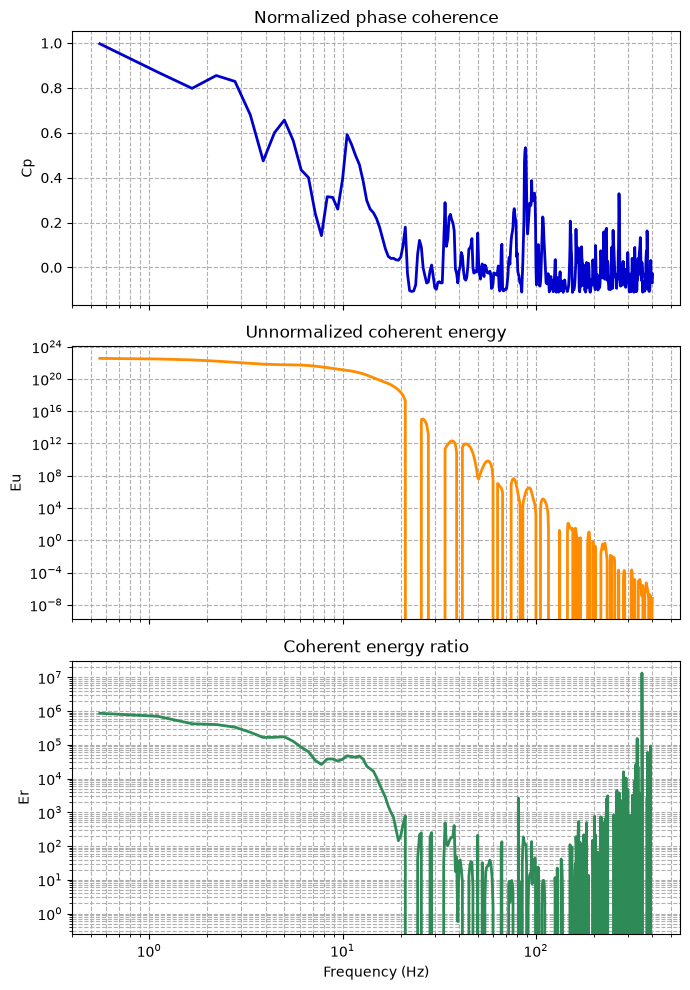

In [5]:

fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)

axes[0].plot(xc.freq, xc.Cp, linewidth=2.0, color="mediumblue")
axes[0].set_ylabel("Cp")
axes[0].set_title("Normalized phase coherence")

axes[1].plot(xc.freq, xc.Eu, linewidth=2.0, color="darkorange")
axes[1].set_ylabel("Eu")
axes[1].set_title("Unnormalized coherent energy")
axes[1].set_yscale("log")


axes[2].plot(xc.freq, xc.Er, linewidth=2.0, color="seagreen")
axes[2].set_ylabel("Er")
axes[2].set_title("Coherent energy ratio")
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_yscale("log")

for ax in axes:
    ax.set_xscale("log")
    ax.grid(True, which="both", linestyle="--")

fig.tight_layout()
plt.show()